In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

df = pd.read_csv("instagram_usage_lifestyle.csv")

In [5]:
print(df.columns)

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

In [8]:
# Seaborn style
sns.set_theme(style="white")

# Create categories
df["usage_category"] = pd.cut(
    df["daily_active_minutes_instagram"],
    bins=[0, 60, 180, 600],
    labels=["Low", "Medium", "High"]
)

df["stress_category"] = pd.cut(
    df["perceived_stress_score"],
    bins=[0, 3, 6, 10],
    labels=["Low", "Medium", "High"]
)

C:\Users\david\AppData\Local\Temp\ipykernel_31064\1156818286.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


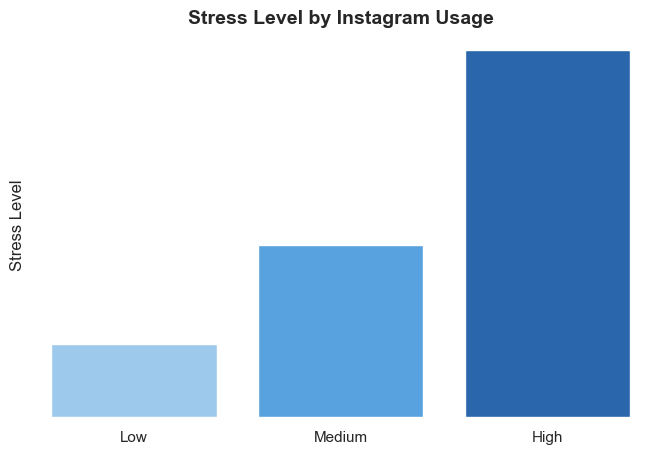

In [9]:
# STRESS LEVEL BY INSTAGRAM USAGE
# ==========================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="usage_category",
    y="perceived_stress_score",
    palette=["#90CAF9", "#42A5F5", "#1565C0"],
    errorbar=None
)

sns.despine(left=True, bottom=True)

plt.title(
    "Stress Level by Instagram Usage",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Stress Level")
plt.yticks([])

plt.show()

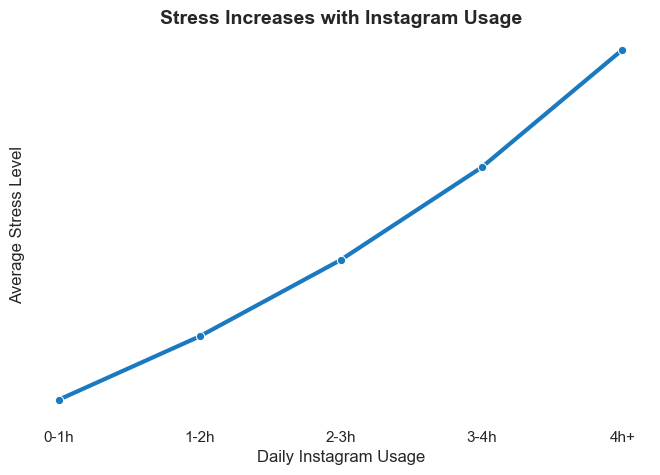

In [11]:
#CHART 2 — AVERAGE STRESS BY USAGE RANGE

# Create usage ranges
df["usage_range"] = pd.cut(
    df["daily_active_minutes_instagram"],
    bins=[0, 60, 120, 180, 240, 600],
    labels=[
        "0-1h",
        "1-2h",
        "2-3h",
        "3-4h",
        "4h+"
    ]
)

# Calculate average stress
usage_stress = (
    df.groupby("usage_range")["perceived_stress_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=usage_stress,
    x="usage_range",
    y="perceived_stress_score",
    marker="o",
    linewidth=3,
    color="#1B7ABF"
)

sns.despine(left=True, bottom=True)

plt.title(
    "Stress Increases with Instagram Usage",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Daily Instagram Usage")
plt.ylabel("Average Stress Level")
plt.yticks([])

plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_31064\2606644624.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


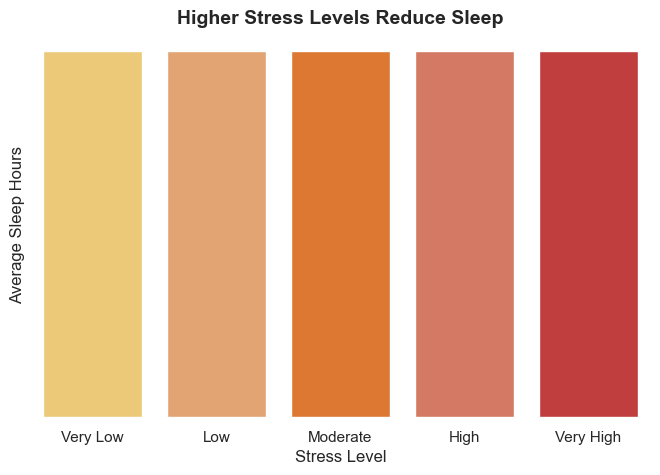

In [14]:
# ==========================================
# NEW CHART 3 — SLEEP HOURS BY STRESS LEVEL
# Using BARPLOT instead of LINEPLOT
# ==========================================

# Create stress ranges
df["stress_range"] = pd.cut(
    df["perceived_stress_score"],
    bins=[0, 2, 4, 6, 8, 10],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="stress_range",
    y="sleep_hours_per_night",
    palette=["#FFD166", "#F4A261", "#F97316", "#E76F51", "#D62828"],
    errorbar=None
)

sns.despine(left=True, bottom=True)

plt.title(
    "Higher Stress Levels Reduce Sleep",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Stress Level")
plt.ylabel("Average Sleep Hours")
plt.yticks([])

plt.show()

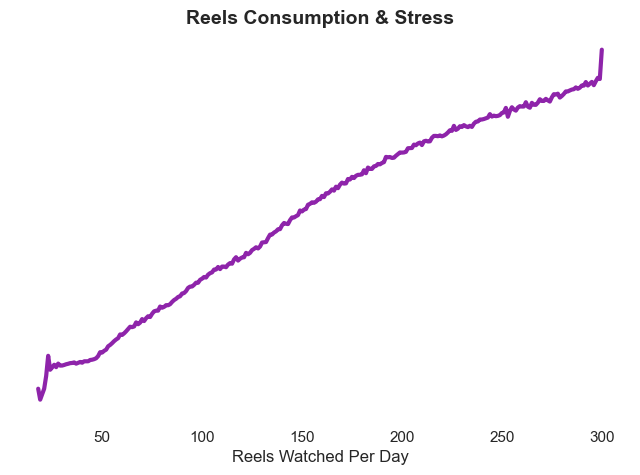

In [15]:
# REELS WATCHED VS STRESS
# ==========================================

reels_data = (
    df.groupby("reels_watched_per_day")["perceived_stress_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=reels_data,
    x="reels_watched_per_day",
    y="perceived_stress_score",
    linewidth=3,
    color="#8E24AA"
)

sns.despine(left=True, bottom=True)

plt.title(
    "Reels Consumption & Stress",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Reels Watched Per Day")
plt.ylabel("")
plt.yticks([])

plt.show()

C:\Users\david\AppData\Local\Temp\ipykernel_31064\3928557230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


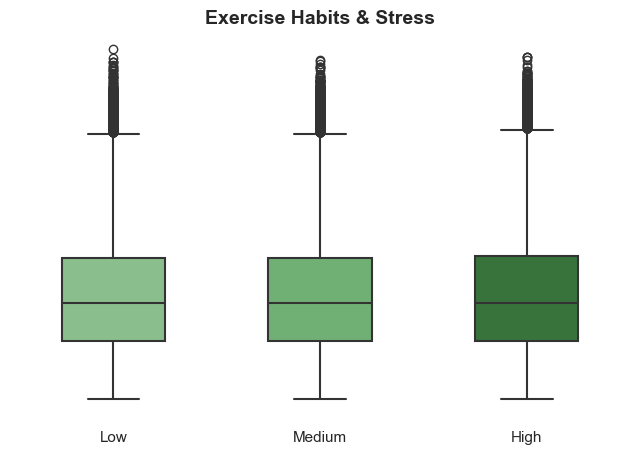

In [16]:
# EXERCISE HABITS & STRESS
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="stress_category",
    y="exercise_hours_per_week",
    palette=["#81C784", "#66BB6A", "#2E7D32"],
    width=0.5,
    linewidth=1.5
)

sns.despine(left=True, bottom=True)

plt.title(
    "Exercise Habits & Stress",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("")
plt.yticks([])

plt.show()

In [ ]:
# HAPPINESS VS STRESS
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="self_reported_happiness",
    y="perceived_stress_score",
    hue="usage_category",
    palette={
        "Low":"#81C784",
        "Medium":"#42A5F5",
        "High":"#EF5350"
    },
    alpha=0.7,
    s=70
)

sns.regplot(
    data=df,
    x="self_reported_happiness",
    y="perceived_stress_score",
    scatter=False,
    color="gray",
    line_kws={"linewidth":2, "linestyle":"--"}
)

sns.despine(left=True, bottom=True)

plt.title(
    "Happiness Decreases as Stress Rises",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Happiness Level")
plt.ylabel("")
plt.yticks([])

plt.legend(frameon=False)

plt.show()